#  ResNet50 — Cracking Defect Detection

This notebook trains a **ResNet50** transfer-learning model to classify surface images as **Cracking** or **No Cracking**.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

---
##  Imports & Configuration

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Cracking/` and `No_Cracking/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [6]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

cracking_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Cracking", "*.jpg")))
no_cracking_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Cracking", "*.jpg")))

print(f"Cracking images    : {len(cracking_files)}")
print(f"No_Cracking images : {len(no_cracking_files)}")

# Label: Cracking = 1, No_Cracking = 0
all_files  = cracking_files + no_cracking_files
all_labels = [1] * len(cracking_files) + [0] * len(no_cracking_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Cracking images    : 1663
No_Cracking images : 2042

Train : 2964
Val   : 370
Test  : 371


### 1.1 — Build `tf.data` pipelines with augmentation

In [7]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1777059135.176855  484310 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5755 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

2026-04-24 20:32:26.072367: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


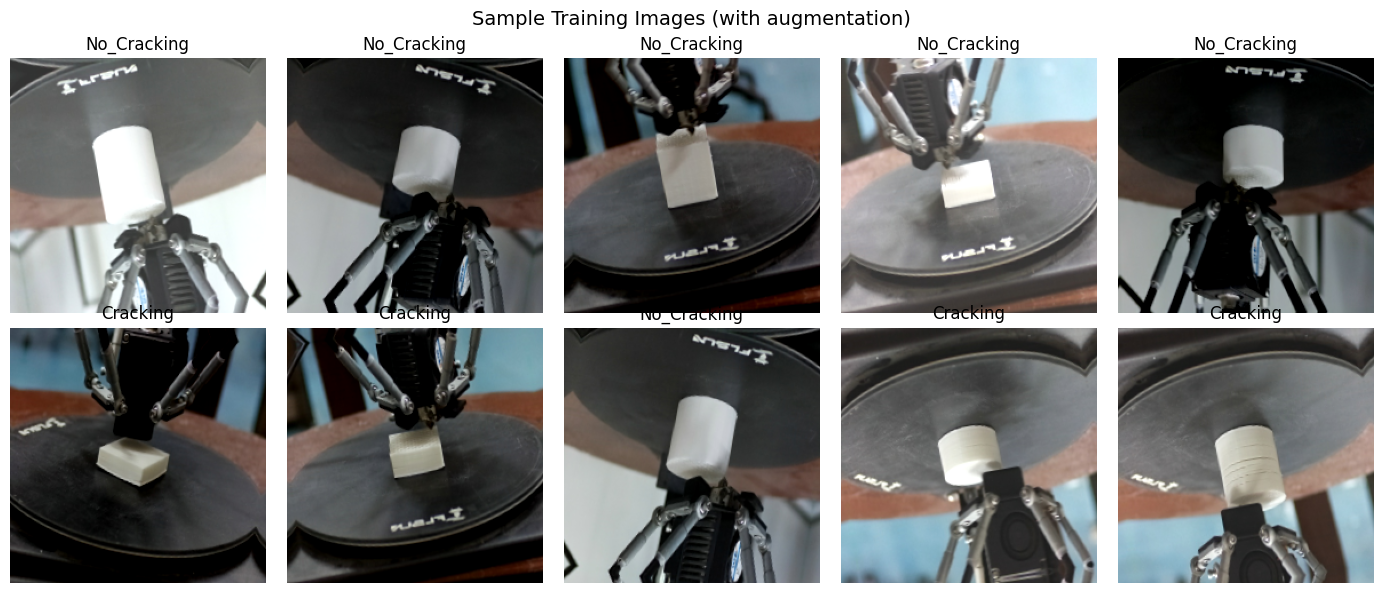

In [8]:
class_names = ["No_Cracking", "Cracking"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

* Load **ResNet50** pretrained on ImageNet (`include_top=False`)
* **Freeze** all base layers
* Add: `GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(1, sigmoid)`

In [9]:
# ---------- Load pretrained base ----------
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

# ---------- Build classification head ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="ResNet50_Cracking")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step
Base model layers : 175
Trainable weights : 0


Model: "ResNet50_Cracking"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [11]:
EPOCHS = 50
BEST_MODEL_PATH = "best_ResNet50_cracking.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1777059182.495654  484772 service.cc:148] XLA service 0x7e1a10001ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777059182.496572  484772 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-04-24 20:33:02.871118: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777059184.553638  484772 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-04-24 20:33:06.346082: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backe

 1/93 ━━━━━━━━━━━━━━━━━━━━ 21:18 14s/step - accuracy: 0.4062 - loss: 1.3539

I0000 00:00:1777059189.700209  484772 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5413 - loss: 0.7727

...


Epoch 44: finished saving model to best_ResNet50_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.8974 - loss: 0.2326 - val_accuracy: 0.9081 - val_loss: 0.1921 - learning_rate: 1.0000e-04
Epoch 45/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8872 - loss: 0.2426
Epoch 45: val_loss improved from 0.19211 to 0.19118, saving model to best_ResNet50_cracking.h5



Epoch 45: finished saving model to best_ResNet50_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8968 - loss: 0.2282 - val_accuracy: 0.9135 - val_loss: 0.1912 - learning_rate: 1.0000e-04
Epoch 46/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8994 - loss: 0.2375
Epoch 46: val_loss improved from 0.19118 to 0.18829, saving model to best_ResNet50_cracking.h5



Epoch 46: finished saving model to best_ResNet50_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.8988 - loss: 0.2373 - val_accuracy: 0.9135 - val_loss: 0.1883 - learning_rate: 1.0000e-04
Epoch 47/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8954 - loss: 0.2277
Epoch 47: val_loss improved from 0.18829 to 0.18684, saving model to best_ResNet50_cracking.h5



Epoch 47: finished saving model to best_ResNet50_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8961 - loss: 0.2328 - val_accuracy: 0.9216 - val_loss: 0.1868 - learning_rate: 1.0000e-04
Epoch 48/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9006 - loss: 0.2325
Epoch 48: val_loss improved from 0.18684 to 0.18604, saving model to best_ResNet50_cracking.h5



Epoch 48: finished saving model to best_ResNet50_cracking.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8968 - loss: 0.2397 - val_accuracy: 0.9189 - val_loss: 0.1860 - learning_rate: 1.0000e-04
Epoch 49/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9005 - loss: 0.2331
Epoch 49: val_loss did not improve from 0.18604
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9022 - loss: 0.2262 - val_accuracy: 0.9000 - val_loss: 0.2032 - learning_rate: 1.0000e-04
Epoch 50/50
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9034 - loss: 0.2296
Epoch 50: val_loss did not improve from 0.18604
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9022 - loss: 0.2297 - val_accuracy: 0.9054 - val_loss: 0.1929 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 48.

✅ Training complete.


---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [12]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

2026-04-24 20:39:55.683273: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[19,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[19,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-04-24 20:39:55.985486: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[19,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[19,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 533ms/step
Test samples : 371


### 5.2 — Classification metrics

In [13]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.9030
  Precision : 0.8800
  Recall    : 0.9112
  F1-Score  : 0.8953

              precision    recall  f1-score   support

 No_Cracking       0.92      0.90      0.91       202
    Cracking       0.88      0.91      0.90       169

    accuracy                           0.90       371
   macro avg       0.90      0.90      0.90       371
weighted avg       0.90      0.90      0.90       371



### 5.3 — Confusion Matrix

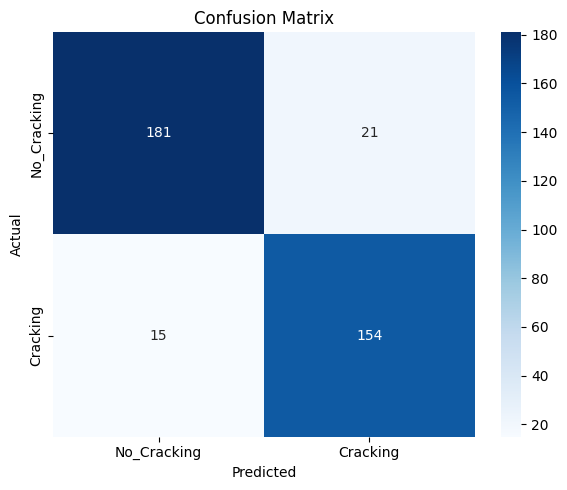

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

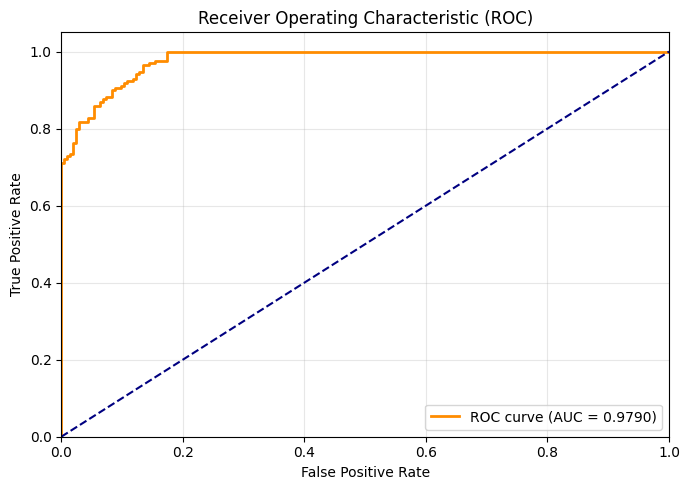

In [15]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

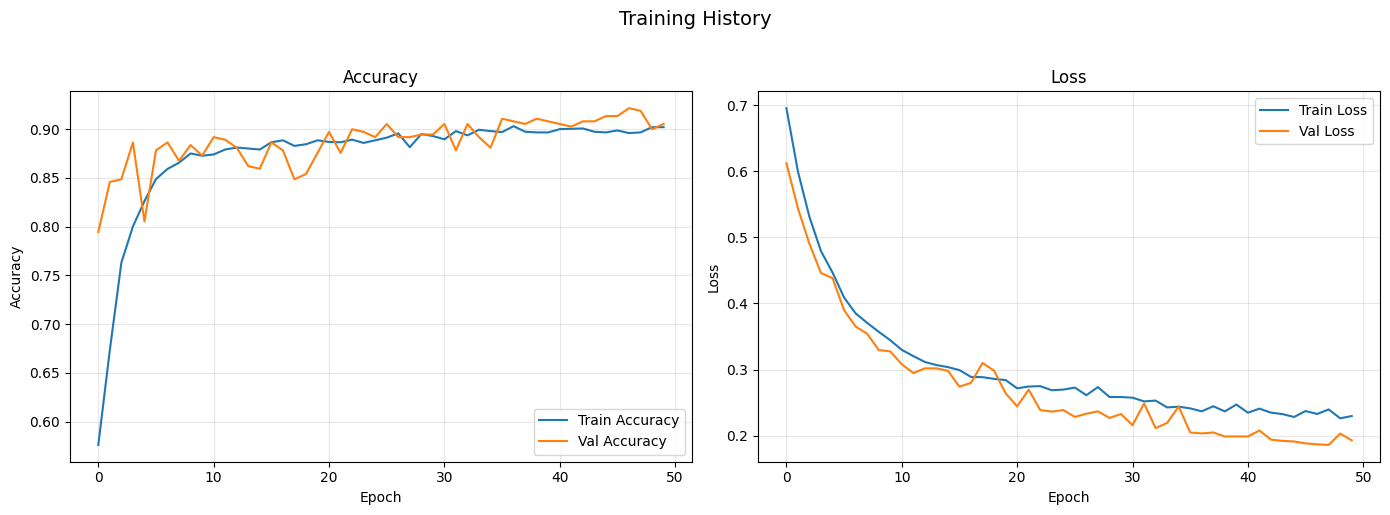

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [17]:
# 1) Save as .h5
H5_PATH = "ResNet50_cracking_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = "ResNet50_cracking_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       → ResNet50_cracking_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=ResNet50_cracking_savedmodel.

---
### ✅ Done!

The trained ResNet50 model for **Cracking vs No_Cracking** detection is now saved and ready for deployment or TFLite conversion.